Project :- STUDENT PERFORMANCE PREDICTION

TOPIC :- DATA ANALYSIS AND PREDICTION

Subject  :- INTRODUCTION TO COGNITIVE COMPUTING

In [1]:
#importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
#---------------
#  LOAD DATA
#---------------

df_performance = pd.read_csv('StudentsPerformance.csv')

# data Overview
print("First 5 Rows:")
display(df_performance.head())

print("\nDataset Info:")
df_performance.info()

print("\nSummary Statistics:")
display(df_performance.describe())


First 5 Rows:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB

Summary Statistics:


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [3]:
#---------------------
# CHECK MISSING VALUES
#---------------------

print("\n🔹 Missing Values:")
print(df_performance.isnull().sum())



🔹 Missing Values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


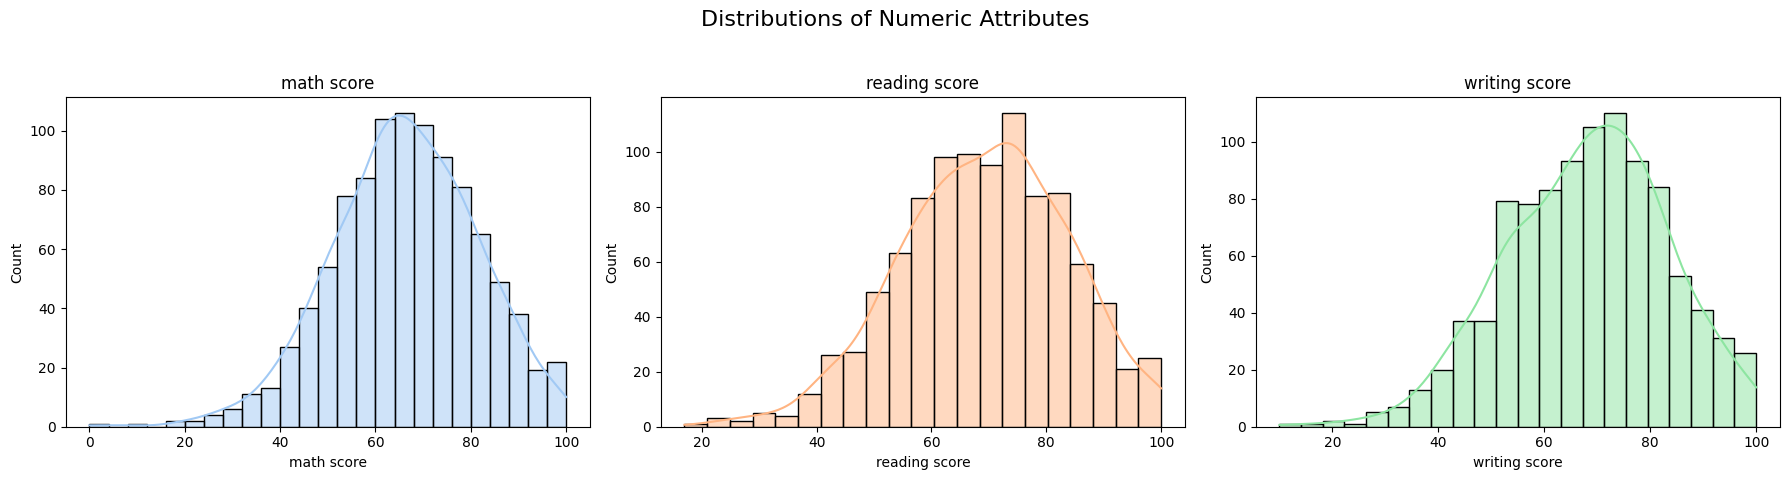

In [4]:

# -----------------------------
#  VISUALIZE DATA DISTRIBUTIONS
# -----------------------------

# Select numeric columns only
numeric_columns = df_performance.select_dtypes(include=['number']).columns

# Set up subplots to visualize all numeric columns
num_plots = len(numeric_columns)
cols = 3
rows = (num_plots + cols - 1) // cols

fig, axs = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axs = axs.flatten()

# Create histogram with KDE for each numeric column
for i, col in enumerate(numeric_columns):
    sns.histplot(df_performance[col], kde=True, ax=axs[i], color=sns.color_palette("pastel")[i % 10])
    axs[i].set_title(col)

# Hide any unused subplots
for j in range(i + 1, len(axs)):
    axs[j].axis('off')

plt.suptitle("Distributions of Numeric Attributes", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


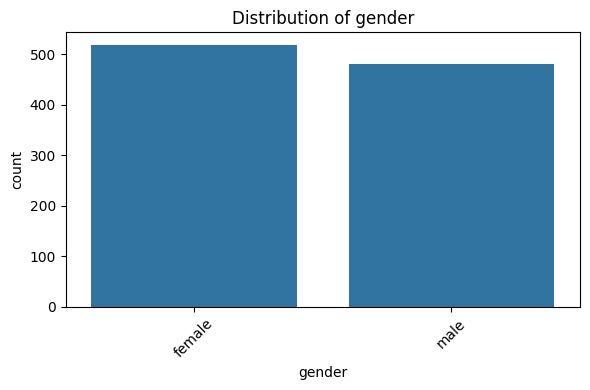

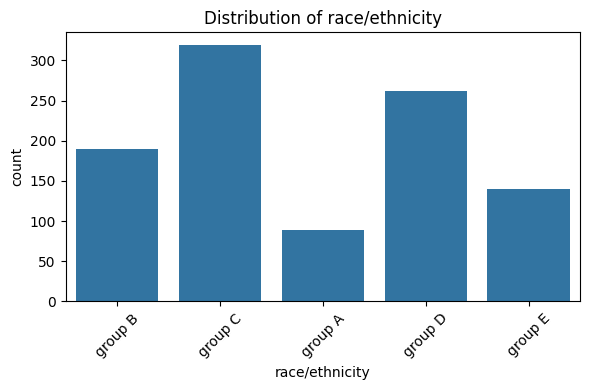

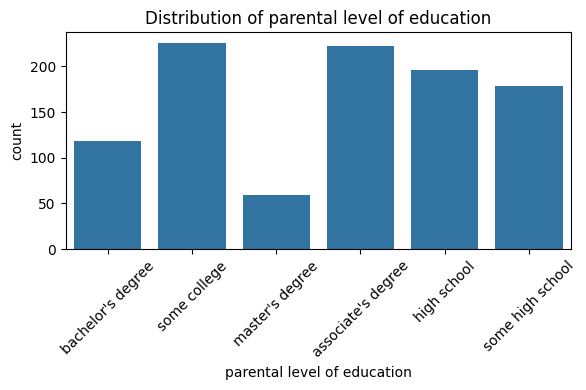

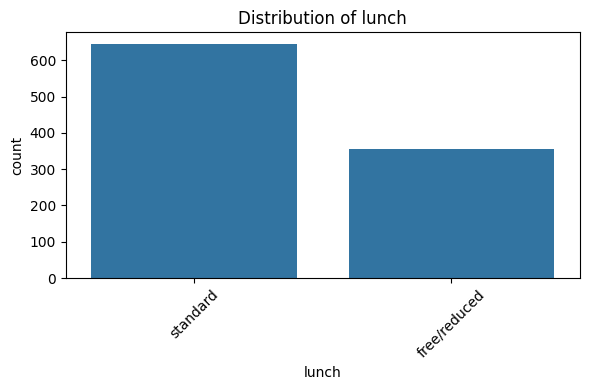

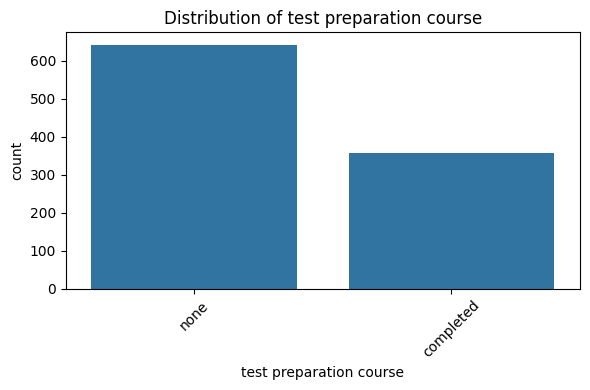

In [5]:
# Categorical Variables
categorical_cols = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df_performance, x=col)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [6]:
# ------------------------------
#  ENCODE CATEGORICAL VARIABLES
# ------------------------------
df_encoded = pd.get_dummies(df_performance, columns=categorical_cols, drop_first=True)


In [7]:
# ----------------------
# CREATE TARGET VARIABLE
# ----------------------
df_encoded['average_score'] = df_performance[['math score', 'reading score', 'writing score']].mean(axis=1)
df_encoded['pass_fail'] = np.where(df_encoded['average_score'] >= 50, 1, 0)
df_encoded.drop(['average_score'], axis=1, inplace=True)

In [8]:
# -------------------------------
# FEATURE SCALING (SCORES)
# -------------------------------
scaler = StandardScaler()
score_features = ['math score', 'reading score', 'writing score']
df_encoded[score_features] = scaler.fit_transform(df_encoded[score_features])

In [9]:
# ------------------
# TRAIN-TEST SPLIT
# ------------------
X = df_encoded.drop('pass_fail', axis=1)
y = df_encoded['pass_fail']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [10]:
# ---------------------
#   TRAIN MODEL
# ---------------------

# Logistic Regression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

LogisticRegression()

In [11]:
# ---------------------
#   TRAIN MODELS
# ---------------------

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [12]:
# ------------------------------
#  PREDICT VALUES ON TEST SET 
# ------------------------------

# Logistic Regression Predictions
y_pred_logreg = logreg.predict(X_test)
print("Logistic Regression Predictions (first 10):")
print(y_pred_logreg[:10])

# Random Forest Predictions
y_pred_rf = rf.predict(X_test)
print("\nRandom Forest Predictions (first 10):")
print(y_pred_rf[:10])

# actual- value and predicted value
print("\n Comparison with Actual Labels (first 10):")
comparison_df = pd.DataFrame({
    "Actual": y_test[:10].values,
    "LogReg_Predicted": y_pred_logreg[:10],
    "RF_Predicted": y_pred_rf[:10]
})
display(comparison_df)


Logistic Regression Predictions (first 10):
[1 0 1 1 0 1 1 1 1 1]

Random Forest Predictions (first 10):
[1 0 1 1 0 1 1 1 1 1]

 Comparison with Actual Labels (first 10):


,Actual,LogReg_Predicted,RF_Predicted
0,1,1,1
1,0,0,0
2,1,1,1
3,1,1,1
4,0,0,0
5,1,1,1
6,1,1,1
7,1,1,1
8,1,1,1
9,1,1,1


In [13]:
# -----------------
#  EVALUATE MODEL
# -----------------
def evaluate_model(model, name):

    print(f"\n===== {name} Evaluation =====")
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, y_proba):.2f})')



===== Logistic Regression Evaluation =====
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.86      0.90        21
           1       0.98      0.99      0.99       179

    accuracy                           0.98       200
   macro avg       0.97      0.93      0.94       200
weighted avg       0.98      0.98      0.98       200

Confusion Matrix:
 [[ 18   3]
 [  1 178]]
ROC-AUC Score: 0.9984

===== Random Forest Evaluation =====
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.90      0.93        21
           1       0.99      0.99      0.99       179

    accuracy                           0.98       200
   macro avg       0.97      0.95      0.96       200
weighted avg       0.98      0.98      0.98       200

Confusion Matrix:
 [[ 19   2]
 [  1 178]]
ROC-AUC Score: 0.9981


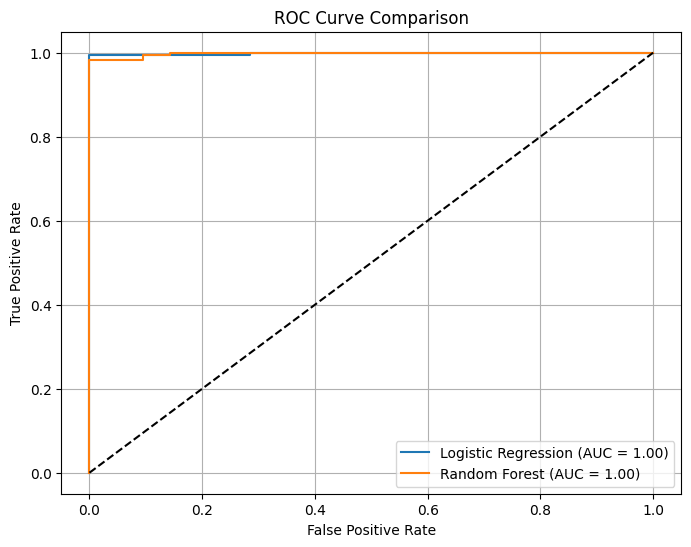

In [14]:
# Plot ROC Curves
plt.figure(figsize=(8,6))
evaluate_model(logreg, "Logistic Regression")
evaluate_model(rf, "Random Forest")
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

C:\Users\mahaj\AppData\Local\Temp\ipykernel_5380\4273308335.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df.head(10), x='Importance', y='Feature', palette='viridis')


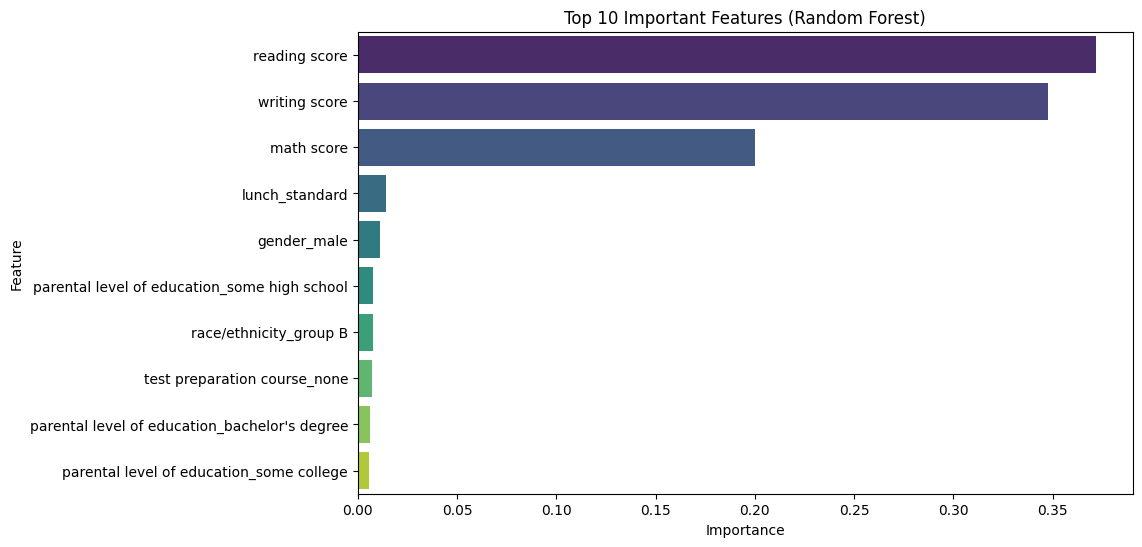

In [15]:
# ----------------------------------
# FEATURE IMPORTANCE (Random Forest)
# ----------------------------------
importances = rf.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title("Top 10 Important Features (Random Forest)")
plt.show()

In [16]:
# ----------------
#   CONCLUSION
# ----------------
"""
- Logistic Regression is a good baseline with interpretable coefficients.
- Random Forest shows superior performance and gives insight into feature importance.
- ROC-AUC gives a better understanding of class separability.
- Most important features are subject scores and some demographic categories.
"""

'\n- Logistic Regression is a good baseline with interpretable coefficients.\n- Random Forest shows superior performance and gives insight into feature importance.\n- ROC-AUC gives a better understanding of class separability.\n- Most important features are subject scores and some demographic categories.\n'